# 💡 한눈에 정리하는 머신러닝 기초: 지도학습(Supervised Learning) 완전 정복

머신러닝의 가장 기본적이면서도 강력한 뼈대가 되는 **지도학습(Supervised Learning)** 복습 노트입니다.

지도학습의 핵심은 **'정답(Label)이 있는 데이터'를 모델에게 보여주며 학습시킨다는 점**입니다.

예측하려는 타겟 데이터(Y)의 성격에 따라 크게

- **회귀(Regression)**

- **분류(Classification)**

두 가지 유형으로 나뉩니다.

두 개념의 작동 원리부터 핵심 알고리즘, 실전 코드까지 깔끔하게 복습해 봅시다!

---

## Part 1. 회귀 (Regression): "연속적인 숫자를 예측하다"

회귀는 집값, 내일의 기온, 매출액처럼
**연속적인 숫자(실수값)**
를 예측하는 것이 목표입니다.

```
입력값 (X)  ──>  모델 (패턴 발견)  ──>  예측값 (Y)
```

1. **손실 함수 (Loss Function)**: 모델이 예측한 값과 실제 데이터 값의 차이(오차)를 계산하는 식입니다.

2. **경사하강법 (Gradient Descent)**: 이 오차(Loss)가 '가장 작아지는' 지점을 향해 모델의 파라미터를 조금씩 조정하며 최적의 선(또는 면)을 찾아 나가는 알고리즘입니다.

> **한 줄 정리**  
> 실제값과 예측값의 오차(Loss Function)가 최소가 되는 모델의 파라미터를 **경사하강법**을 통해 찾아내는 과정이 곧 회귀 분석의 핵심입니다.

### 1-1. 단순 선형 회귀 (Simple Linear Regression)
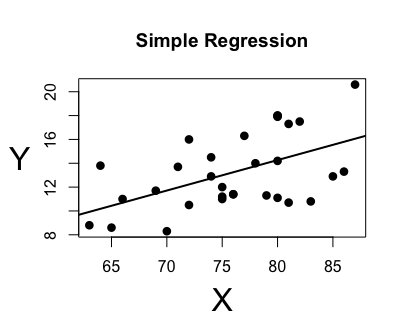
* **특징**: 가장 클래식하고 직관적인 회귀 방식입니다. 입력값(독립변수 $X$)이 단 **1개**일 때 사용합니다.
* **구조**: 우리에게 친숙한 1차 함수 구조를 가집니다.
  $$Y = aX + b$$

### 1-2. 다중 선형 회귀 (Multiple Linear Regression)
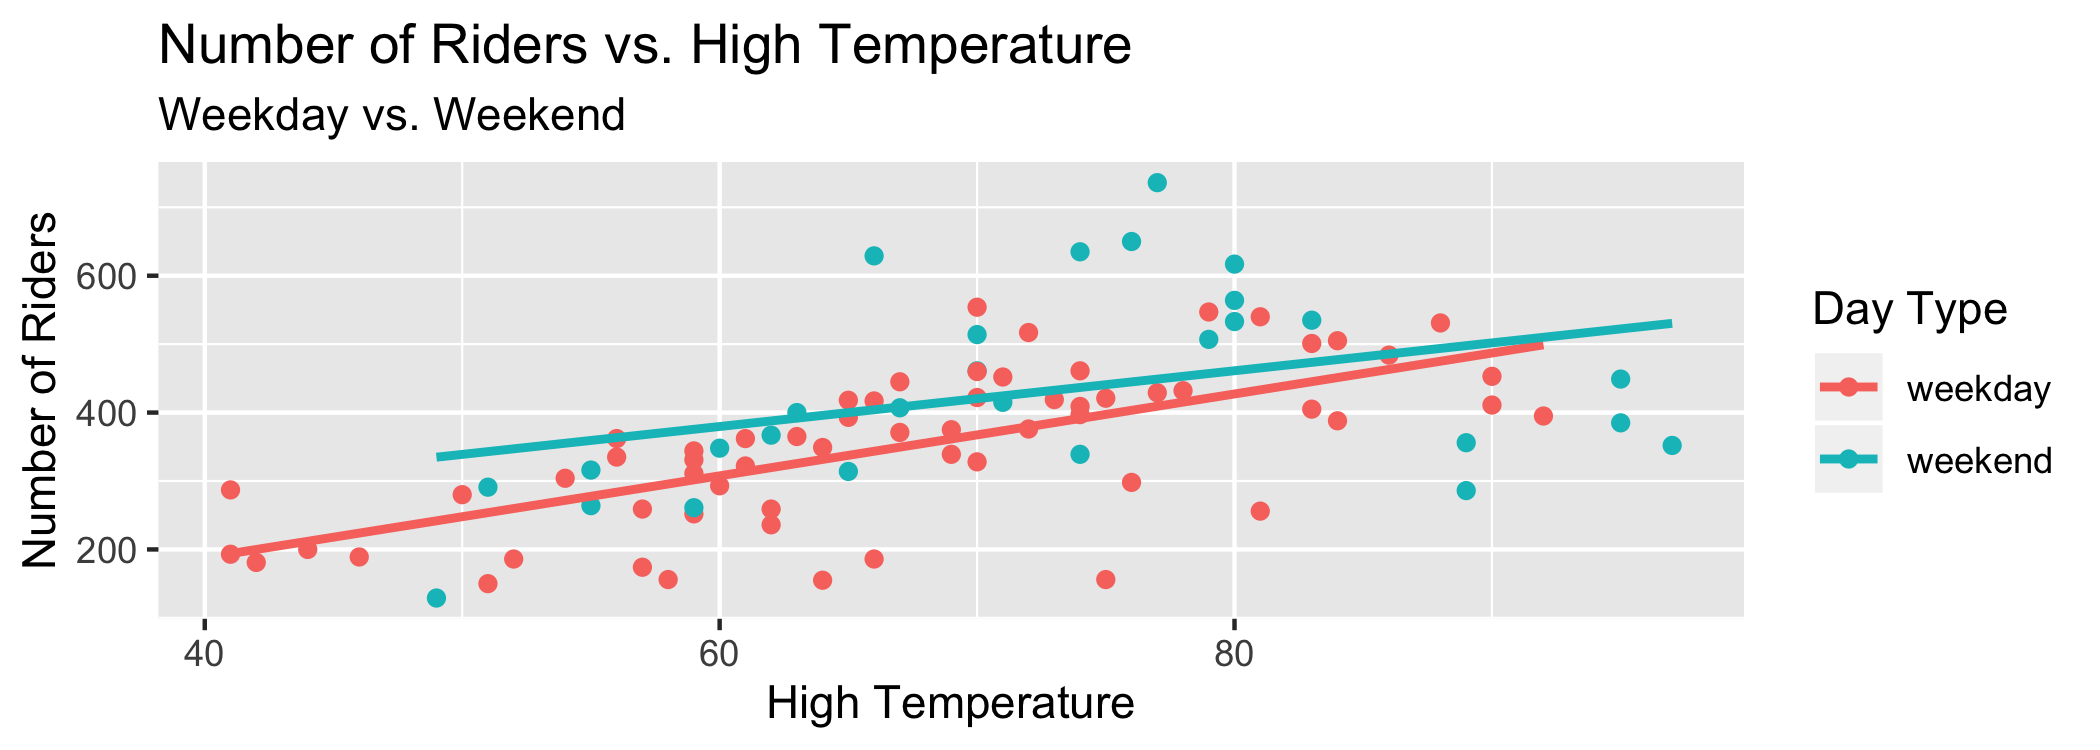
* **특징**: 현실 세계의 문제는 한 가지 원인으로만 결정되지 않죠. 여러 개의 입력값($X_1, X_2, \dots$)을 바탕으로 결과를 예측합니다.
* **구조**:
  $$Y = aX_1 + bX_2 + cX_3 + \dots$$
* **⚠️ 주의점 (다중공선성)**: 입력 변수들끼리 서로 강한 상관관계를 가질 때(예: '평수'와 '방의 개수'), 한 변수가 움직일 때 다른 변수도 같이 출렁이면서 결과의 신뢰성(해석력)이 크게 낮아질 수 있습니다.

### 1-3. 다항 회귀 (Polynomial Regression)
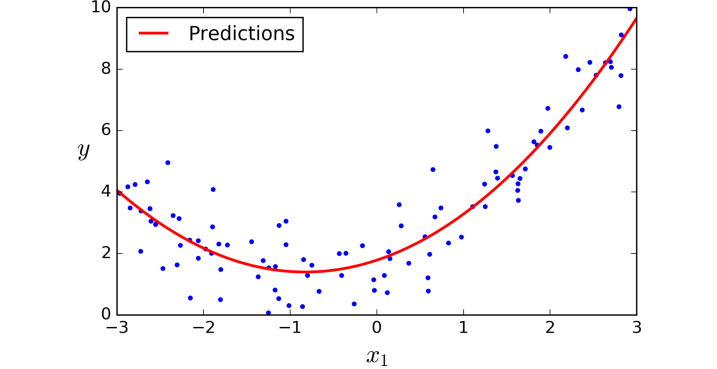
* **특징**: 데이터의 분포가 곧은 직선이 아닌 둥근 곡선 형태(비선형)일 때 사용합니다. 일차함수로는 도저히 설명할 수 없을 때 차수를 높여 대응합니다.
* **⚠️ 주의점 (과적합)**: 오차를 줄이겠다고 차수(degree)를 무리하게 높이면, 훈련 데이터에만 완벽히 들어맞고 실제 새로운 데이터는 전혀 맞추지 못하는 **과적합(Overfitting)** 상태에 빠지게 됩니다.

### 💻 실전 코드로 보는 회귀

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 가상의 데이터 생성 (X: 학습 시간, y: 성적)
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# 1. 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 단순/다중 선형회귀
# 2-1. 모델 생성
model = LinearRegression()

# 2-2. 훈련
model.fit(X_train, y_train)

# 모델의 결정계수(R²) 확인 및 회귀계수 반환
print("테스트 데이터 점수(R²):", model.score(X_test, y_test))
print("회귀 계수(a, 기울기):", model.coef_)
print("편향(b, 절편):", model.intercept_)

print("-" * 50)
# --------------------------------------------------

# 3. 다항 회귀 (비선형 데이터 전처리)
# 3-1. 모델생성
# degree로 차수 결정, include_bias로 편향(1) 포함 여부 결정
pf = PolynomialFeatures(degree=2, include_bias=True)

# 3-2. 데이터 전처리
X_poly_train = pf.fit_transform(X_train)

# 3-3. 훈련 (전처리 데이터 -> 선형 회귀 모델로 훈련)
# 선형회귀 모델 생성
poly_model = LinearRegression()
# 훈련
poly_model.fit(X_poly_train, y_train)
print("다항 회귀 변환 후 첫 번째 데이터 특성:", X_poly_train[0])

### 1-4. 과적합 방지의 구원투수: 교차 검증과 정규화 (Regularization)

새로운 데이터에 대한 예측 성능이 점점 떨어진다면,
**과적합(Overfitting)**  현상을 해결해야합니다.

이를 해결하기 위해 두 가지 카드를 꺼내 들어야 합니다.

#### ① 검증 과정 고도화
* **홀드아웃(Hold-out)**: 데이터를 Train / Validation / Test 세트로 나누어 검증합니다.

* **K-폴드 교차 검증(K-Fold Cross Validation)**: 데이터를 K개로 쪼개어 번갈아가며 검증용으로 사용하여 모델 성능을 보다 객관적으로 평가합니다.

#### ② 정규화 (Regularization)를 통한 모델 단순화
모델이 너무 복잡해지지 않도록 회귀 계수(가중치)의 크기를 제어(패널티 부여)하는 기법입니다.

* **L1 정규화 (Lasso)**: 중요도가 낮은 가중치(특성)를 **아예 0으로** 만들어 버립니다. 특성 선택 효과가 있지만, 중요한 정보까지 잃어버릴 위험이 있습니다.
* **L2 정규화 (Ridge)**: 중요하지 않은 가중치를 0에 가깝게 **부드럽게 깎아냅니다**. 변수 간 상관관계가 강할 때 잘 작동하며, Lasso에 비해 안정적입니다.
* **엘라스틱넷 (Elastic Net)**: L1과 L2 정규화의 장점을 적절히 섞은 모델입니다. 두 규제 중 무엇을 써야 할지 감이 안 올 때 좋은 선택지입니다.

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# L1 정규화 (Lasso) - alpha가 클수록 정규화 강도가 세집니다.
lasso = Lasso(alpha=10) # 모델 생성
lasso.fit(X_train, y_train) # 훈련

# L2 정규화 (Ridge)
ridge = Ridge(alpha=10) # 모델 생성
ridge.fit(X_train, y_train) # 훈련

# L1 + L2 정규화 (ElasticNet) - l1_ratio로 두 규제의 비율을 조절합니다.
elastic = ElasticNet(alpha=0.001, l1_ratio=0.5) # 모델 생성
elastic.fit(X_train, y_train) # 훈련

print("정규화 모델 설정 완료!")

### 1-5. 회귀 모델 평가지표
회귀의 목적은 '실제값과 예측값의 차이를 최대한 줄이는 것'입니다. 성능을 정량화하기 위해 아래 지표들을 사용합니다.

* **RSS (Residual Sum of Squares)**: 실제값과 예측값의 단순 오차 제곱합. 이상치에 매우 민감합니다.
* **MSE (Mean Squared Error)**: RSS를 데이터 개수로 나눈 평균값. 여전히 이상치에 민감하지만 대표적인 평가지표입니다.
* **MAE (Mean Absolute Error)**: 실제값과 예측값의 오차에 절대값을 씌워 평균한 값. 오차의 단위를 그대로 유지하며, 이상치에 상대적으로 덜 민감합니다.
* **$R^2$ (결정계수)**: 모델이 종속변수의 변동을 얼마나 잘 설명하는지 보여주는 비율입니다. 1에 가까울수록 성능이 좋으며, 모델이 최악일 때는 음수가 나올 수도 있습니다.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 결과값(예측값) 추론
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r_squared:.4f}")

---

## Part 2. 분류 (Classification): "카테고리를 나누다"

예측하고자 하는 타겟(Y)이 연속적인 숫자가 아닌, **이산적인 카테고리(범주)**
일 때 우리는 회귀 대신 분류를 사용합니다.

* **예시**: 참/거짓, 패스/페일, 스팸메일/정상메일, 개/고양이 등

### 2-1. 로지스틱 회귀 (Logistic Regression)
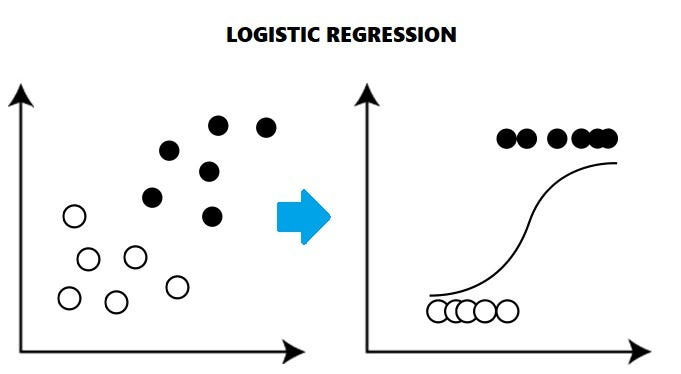
* **개념**: 이름은 회귀이지만 사실은 **이진 분류(Binary Classification)** 모델입니다. 선형 회귀의 예측값($-\infty$에서 $+\infty$)을 **시그모이드(Sigmoid) 함수**에 통과시켜 0과 1 사이의 확률값으로 변환합니다.
* **시그모이드 함수**:
  * 입력값이 커질수록 $1$에 수렴하고, 작아질수록 $0$에 수렴하는 S자형 곡선 함수입니다.
  * 보통 출력된 확률값이 **0.5를 기준**으로 이보다 크면 양성/패스/정상메일/개(1), 작으면 음성/페일/스팸메일/고양이(0)으로 판별합니다.

### 2-2. SVM (Support Vector Machine)
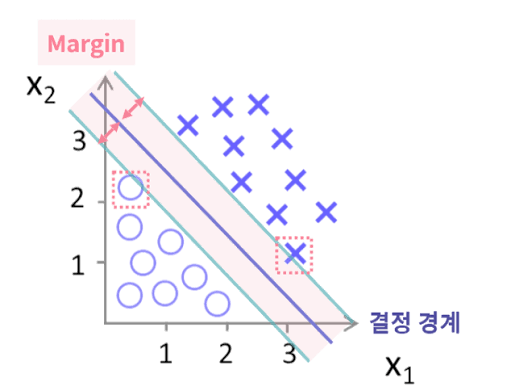
* **개념**: 데이터를 서로 다른 집합으로 구분하는 최적의 **결정 경계(Decision Boundary)**
를 찾는 알고리즘입니다.
* **핵심 용어**:
  * **서포트 벡터 (Support Vector)**: 결정 경계와 가장 가까이 맞닿아 있는 데이터 포인트들입니다.
  * **마진 (Margin)**: 결정 경계와 서포트 벡터 사이의 거리입니다.
* **목표**: SVM은 이 **마진을 최대화**하는 결정 경계를 설계하여 새로운 데이터가 들어왔을 때 오차가 없도록 분류합니다.

### 2-3. 나이브 베이즈 (Naive Bayes)
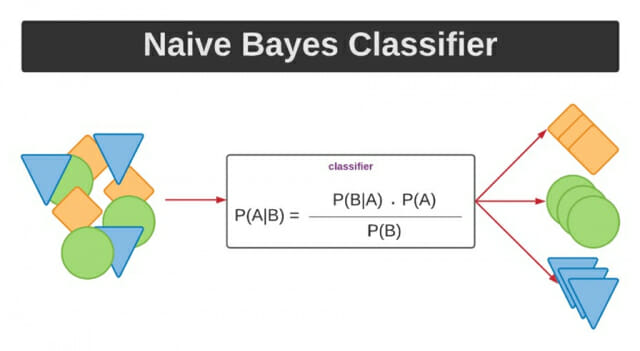
* **개념**: 조건부 확률을 다루는 **베이즈 정리(Bayes' Theorem)**
를 기반으로 한 모델입니다. 텍스트 분류(예: 스팸 메일 필터링)에 자주 쓰입니다.
* **장점**: 모든 특성(단어)들이 서로 독립이라는 가정하에 계산되므로, 학습이 매우 빠르고 적은 데이터로도 좋은 성능을 냅니다.
* **단점**: 실제로 특성 간 독립성이 깨지면(예: 문맥 속 단어들의 연관성) 신뢰도가 떨어지며, 학습 데이터에 없는 범주가 나타나면 확률이 0이 되어 예측이 불가능해집니다.

### 2-4. KNN (K-Nearest Neighbors)
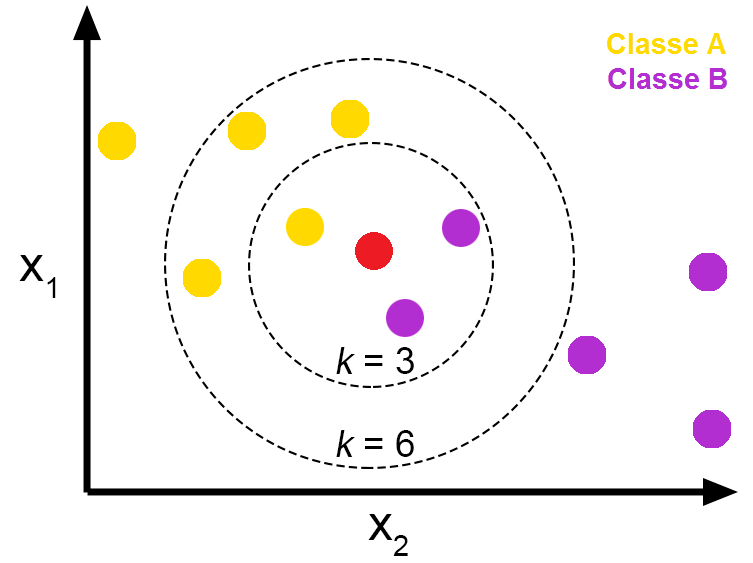
* **개념**: "끼리끼리 유유상종" 알고리즘입니다. 새로운 데이터가 주어졌을 때, 공간상에서 가장 가까운 거리에 있는 **K개의 이웃 데이터**를 확인하고, 이웃들이 가장 많이 속해 있는 집합으로 분류합니다.
* **특징**: 매우 직관적이고 모델 구축이 쉬우나, 최적의 K값에 따라 성능이 크게 좌우됩니다. (이웃들의 다수결 투표가 동률이 나지 않도록 K는 주로 **홀수**로 설정합니다.)

### 💻 실전 코드로 보는 분류 모델들

In [ ]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# 가상의 분류용 데이터셋 생성
X_clf, y_clf = make_classification(n_samples=100, n_features=4, n_classes=2, random_state=42)
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# --------------------------------------------------

# 1. 로지스틱 회귀
# 1-1. 모델 생성
model_lr = LogisticRegression()

# 1-2. 훈련
model_lr.fit(X_c_train, y_c_train)

# 1-3. 결과값(예측값) 추론
pred_lr = model_lr.predict(X_c_test)

# --------------------------------------------------

# 2. SVM
# 2-1. 모델 생성
model_svm = SVC()

# 2-2. 훈련
model_svm.fit(X_c_train, y_c_train)

# 2-3. 결과값(예측값) 추론
pred_svm = model_svm.predict(X_c_test)

# --------------------------------------------------

# 3. 나이브 베이즈
# 3-1. 모델 생성
model_nb = GaussianNB()

# 3-2. 훈련
model_nb.fit(X_c_train, y_c_train)

# 3-3. 결과값(예측값) 추론
pred_nb = model_nb.predict(X_c_test)

# --------------------------------------------------

# 4. KNN (n_neighbors는 되도록 홀수로)
# 4-1. 모델 생성
model_knn = KNeighborsClassifier(n_neighbors=5)

# 4-2. 훈련
model_knn.fit(X_c_train, y_c_train)

# 4-3. 결과값(예측값) 추론
pred_knn = model_knn.predict(X_c_test)

print("분류 모델 4종 학습 및 예측 완료!")

### 2-5. 분류 모델 평가지표 & 혼동 행렬 (Confusion Matrix)

분류 성능을 엄밀하게 평가하기 위해 아래의 오차 행렬을 기반으로 지표들을 계산합니다.

| | 실제 양성 (Positive) | 실제 음성 (Negative) |
|---|---|---|
| **예측 양성 (Positive)** | **TP** (True Positive) | **FP** (False Positive) |
| **예측 음성 (Negative)** | **FN** (False Negative) | **TN** (True Negative) |

* **정확도 (Accuracy)**: 전체 데이터 중 올바르게 분류(TP, TN)한 비율입니다.
  $$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{FP} + \text{TN} + \text{FN}}$$
* **정밀도 (Precision)**: 모델이 Positive라고 예측한 것 중 실제 Positive인 비율입니다. (FP를 낮추는 것이 중요할 때 사용)
  $$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$
* **재현율 (Recall)**: 실제 Positive인 데이터 중 모델이 Positive라고 맞춘 비율입니다. (FN을 낮추는 것이 생명일 때 사용)
  $$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$
* **F1-Score**: 정밀도와 재현율의 조화 평균값으로, 데이터 라벨이 불균형할 때 모델의 전체적인 성능 균형을 평가하기에 적절합니다.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 로지스틱 회귀 모델의 예측값(pred_lr)을 통해 평가지표 확인
accuracy = accuracy_score(y_c_test, pred_lr)
precision = precision_score(y_c_test, pred_lr)
recall = recall_score(y_c_test, pred_lr)
f1 = f1_score(y_c_test, pred_lr)

print(f"[Logistic Regression 평가지표]")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

---

## 📝 마치며

지도학습의 큰 두 축인 **회귀**와 **분류**는 머신러닝 실무에서 가장 기본이 되는 기술입니다.

코드 셀을 위에서부터 차례로 실행(`Shift + Enter`)해 보며 데이터 전처리, 모델 학습, 그리고 평가지표 확인까지의 워크플로우를 완벽하게 체득해 보세요!

새로운 노트북을 열어 아래 플로우를 꼭 실습해보세요.
- 데이터 분류
- 모델 생성
- 훈련
- 예측값(결과값) 확인
- 평가지표 확인

수강생 여러분의 탄탄한 ML 기본기를 항상 응원합니다! 💪